In [5]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from math import pi
import itertools

In [6]:
# ==========================================
# 1. CONFIGURATION & STYLE
# ==========================================
# Robust path finding
BASE_DIR = Path("results_attained")
if not BASE_DIR.exists():
    BASE_DIR = Path("../results_attained")

OUTPUT_DIR = Path("Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# IEEE Publication Style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# Consistent Colors & Markers
COLORS = {
    "CLIP": "#0072B2",       # Blue
    "CLIP_LORA": "#D55E00",  # Vermillion (Red/Orange)
    "FROZEN": "#009E73"      # Bluish Green
}
# Updated markers as requested (LORA = X)
MARKERS = {"CLIP": "o", "CLIP_LORA": "X", "FROZEN": "s"} 
LINETYPES = {"CLIP": "--", "CLIP_LORA": "-", "FROZEN": "-."}

print(f"✓ Configuration loaded. Saving plots to: {OUTPUT_DIR.resolve()}")

✓ Configuration loaded. Saving plots to: /sda/usama/production_code/visual_testing/Results


In [7]:
# ==========================================
# 2. DATA LOADING
# ==========================================
def load_all_data():
    records = []
    model_stats = {}
    
    # Define models to look for
    models_to_check = ["CLIP", "CLIP_LORA", "FROZEN"]

    for model in models_to_check:
        model_path = BASE_DIR / model
        metrics_file = model_path / "metrics.json"
        
        # Check file existence
        if not metrics_file.exists():
            print(f"⚠️  Skipping {model}: {metrics_file} not found.")
            continue
            
        try:
            with open(metrics_file, 'r') as f:
                data = json.load(f)
        except json.JSONDecodeError:
            print(f"❌ Error decoding JSON for {model}")
            continue

        # --- Extract Stats (Graceful Fallback) ---
        lat_data = data.get("latency", {})
        mem_data = data.get("memory", {})
        param_data = data.get("parameters", {})
        eval_data = data.get("evaluation_results", {})

        throughput = lat_data.get("throughput_samples_per_second", 0) or 0
        peak_mem = mem_data.get("inference_peak_gpu_mb", 0) or 0
        
        # Params calculation
        trainable = param_data.get("trainable_parameters", 0) or 0
        frozen = param_data.get("frozen_parameters", 0) or 0
        params_m = (trainable + frozen) / 1e6

        # Initialize stats dict for this model
        model_stats[model] = {
            "Throughput": throughput,
            "Memory": peak_mem,
            "Params_M": params_m
        }

        # Track LP accuracies for average calculation
        lp_accuracies = []

        # --- Iterate Datasets ---
        for dataset_name, dataset_metrics in eval_data.items():
            ds_clean = dataset_name.upper()

            # 1. Linear Probe
            if "linear_probe" in dataset_metrics:
                lp_data = dataset_metrics["linear_probe"]
                acc = lp_data.get("accuracy", lp_data.get("top1", 0))
                lp_accuracies.append(acc)
                records.append({
                    "Model": model, "Task": "Linear Probe",
                    "Dataset": ds_clean, "Shots": "Full", "Accuracy": acc
                })

            # 2. Zero Shot
            if "zero_shot" in dataset_metrics:
                zs_data = dataset_metrics["zero_shot"]
                acc = zs_data.get("top1_accuracy", zs_data.get("accuracy", 0))
                records.append({
                    "Model": model, "Task": "Zero-Shot",
                    "Dataset": ds_clean, "Shots": 0, "Accuracy": acc
                })

            # 3. Few Shot
            if "few_shot" in dataset_metrics:
                for shot_key, shot_data in dataset_metrics["few_shot"].items():
                    try:
                        shot_val = int(shot_key.split('-')[0])
                    except ValueError:
                        continue 

                    acc = shot_data.get("accuracy_mean", 0)
                    std = shot_data.get("accuracy_std", 0)

                    records.append({
                        "Model": model, "Task": "Few-Shot",
                        "Dataset": ds_clean, "Shots": shot_val, 
                        "Accuracy": acc, "Std": std
                    })

        # Calculate Average Linear Probe Accuracy for Pareto Plot
        avg_lp = np.mean(lp_accuracies) if lp_accuracies else 0
        model_stats[model]["Avg_LP_Acc"] = avg_lp

    return pd.DataFrame(records), model_stats

In [13]:
# ==========================================
# 3. PLOTTING FUNCTIONS
# ==========================================

def plot_efficiency(model_stats):
    """Plots inference throughput comparison (Fig 1)."""
    if not model_stats: 
        print("Warning: model_stats is empty. Skipping efficiency plot.")
        return

    data = pd.DataFrame(model_stats).T.reset_index().rename(columns={"index": "Model"})
    
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(
        data=data, x="Model", y="Throughput", hue="Model", 
        palette=COLORS, edgecolor="black", linewidth=1.5, legend=False
    )
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=14, fontweight='bold', 
                        xytext=(0, 5), textcoords='offset points')

    plt.title("Inference Efficiency (Fair Comparison)", fontweight='bold', pad=15)
    plt.ylabel("Throughput (Samples/Sec) ↑")
    plt.xlabel("")
    
    if not data["Throughput"].empty:
        plt.ylim(0, data["Throughput"].max() * 1.15) 
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Fig1_Efficiency.png")
    plt.show()
    print("✓ Saved Fig1_Efficiency.png")

def plot_pareto_final(model_stats):
    """Plots Pareto Frontier: Speed vs Accuracy vs Size (Fig 2)."""
    if not model_stats:
        print("Model stats are empty!")
        return

    data = (
        pd.DataFrame(model_stats)
        .T.reset_index()
        .rename(columns={"index": "Model", "Avg_LP_Acc": "Avg_Acc"})
    )

    plt.figure(figsize=(10.5, 6.5))

    ax = sns.scatterplot(
        data=data, x="Throughput", y="Avg_Acc", hue="Model", style="Model",
        palette=COLORS, markers=MARKERS, s=220, edgecolor="black", 
        linewidth=1.5, alpha=0.95, legend=True
    )

    offsets = {
        "CLIP": (35, -10),
        "CLIP_LORA": (35, -35),
        "FROZEN": (35, 10),
    }

    for _, row in data.iterrows():
        dx, dy = offsets.get(row["Model"], (35, 0))
        ax.annotate(
            f"{row['Model']}\n{int(row['Params_M'])}M Params",
            xy=(row["Throughput"], row["Avg_Acc"]),
            xytext=(dx, dy), textcoords="offset points",
            ha="left", va="center", fontsize=12, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="#888", alpha=0.95, boxstyle="round,pad=0.4"),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="black", shrinkA=0, shrinkB=5, connectionstyle="arc3,rad=0.1"),
        )

    ax.legend(title="Model", title_fontsize=12, fontsize=11, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
    ax.set_title("Pareto Frontier: Speed vs. Accuracy vs. Size", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("Inference Speed (Samples / Sec)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Avg. Linear Probe Accuracy (%)", fontsize=13, fontweight="bold")

    if not data.empty:
        ax.set_xlim(0, data["Throughput"].max() * 1.25)
        ax.set_ylim(data["Avg_Acc"].min() - 2, data["Avg_Acc"].max() + 4)

    ax.grid(True, linestyle="--", alpha=0.88)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Fig2_Pareto_Frontier.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✓ Saved Fig2_Pareto_Frontier.png")

def plot_radar(df):
    """Plots Radar Chart for Linear Probe balance (Fig 3)."""
    lp_df = df[df["Task"] == "Linear Probe"].copy()
    if lp_df.empty: 
        print("No Linear Probe data found for radar chart.")
        return

    name_map = {
        "CIFAR100": "CIFAR-100", "FOOD101": "Food-101",
        "FLOWERS102": "Flowers-102", "DTD": "DTD (Textures)", "EUROSAT": "EuroSAT"
    }
    lp_df["Dataset"] = lp_df["Dataset"].apply(lambda x: name_map.get(x, x))

    # Pivot: Index=Model, Columns=Dataset, Values=Accuracy
    pivot = lp_df.pivot(index="Model", columns="Dataset", values="Accuracy")
    labels = list(pivot.columns)
    num_vars = len(labels)
    
    # Safe Hex Colors
    safe_hex_colors = [COLORS["CLIP"], COLORS["CLIP_LORA"], COLORS["FROZEN"]]
    color_cycle = itertools.cycle(safe_hex_colors)
    unique_models = pivot.index.tolist()
    model_colors = {model: next(color_cycle) for model in unique_models}

    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for model in pivot.index:
        values = pivot.loc[model].tolist()
        values += values[:1]
        c = model_colors[model]
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=model, color=c)
        ax.fill(angles, values, color=c, alpha=0.1)
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], labels, size=12, fontweight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([20, 40, 60, 80], ["20", "40", "60", "80"], color="grey", size=10)
    plt.ylim(0, 100)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), title="Model")
    plt.title("Dataset Performance Balance", fontweight='bold', y=1.08)
    plt.savefig(OUTPUT_DIR / "Fig3_Radar_Balance.png")
    plt.show()
    print("✓ Saved Fig3_Radar_Balance.png")

def plot_few_shot_curves(df):
    """Plots Few-Shot learning curves (Fig 4)."""
    data = df[df["Task"] == "Few-Shot"].copy()
    if data.empty:
        print("No Few-Shot data found.")
        return

    name_map = {
        "CIFAR100": "CIFAR-100", "FOOD101": "Food-101",
        "FLOWERS102": "Flowers-102", "DTD": "Describable Textures Dataset", "EUROSAT": "EuroSAT"
    }
    data["Dataset"] = data["Dataset"].apply(lambda x: name_map.get(x, x))

    g = sns.FacetGrid(
        data, col="Dataset", col_wrap=2, height=4, aspect=1.1, sharey=False
    )

    # 1. Plot the main lines (Thinner lines and smaller markers)
    g.map_dataframe(
        sns.lineplot, x="Shots", y="Accuracy", hue="Model", style="Model",
        markers=MARKERS, palette=COLORS, 
        linewidth=2,      # Reduced from 3
        markersize=7,     # Reduced from 10
        alpha=0.9
    )

    # 2. Add Vertical Std Dev Lines (Thinner error bars)
    def plot_err(data, **kws):
        for model, grp in data.groupby("Model"):
            # Ensure data is sorted by shots so error bars align correctly
            grp = grp.sort_values("Shots")
            plt.errorbar(
                x=grp["Shots"], y=grp["Accuracy"], yerr=grp["Std"], 
                fmt='none',  # No line connecting points (just bars)
                ecolor=COLORS[model], # Use model-specific color
                capsize=3,        # Slightly smaller caps
                elinewidth=1.2,   # Thinner vertical line
                markeredgewidth=1 # Thinner marker edges
            )
    g.map_dataframe(plot_err)

    g.set_titles(col_template="{col_name}", fontweight="bold", size=14)
    g.set_axis_labels("Shots (k)", "Accuracy (%)")
    g.set(xticks=[1, 2, 4, 8, 16])

    # Legend handling on last axis
    last_ax = g.axes[-1] 
    handles, labels = last_ax.get_legend_handles_labels()
    # Filter legend to avoid duplicates from errorbar handles if any appear
    last_ax.legend(
        handles=handles, labels=labels, title="Model", title_fontsize=12,
        fontsize=11, bbox_to_anchor=(1.5, 0.6), loc='center left', frameon=False
    )

    g.fig.subplots_adjust(wspace=0.25, hspace=0.35)
    plt.suptitle("Few-Shot Adaptability Analysis", y=1.03, fontweight="bold", size=16)
    plt.savefig(OUTPUT_DIR / "Fig4_FewShot_Curves.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("✓ Saved Fig4_FewShot_Curves.png")

Starting Analysis...
✓ Loaded 100 data points and 3 model stats.


/tmp/ipykernel_40862/434089929.py:32: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0, data["Throughput"].max() * 1.15)


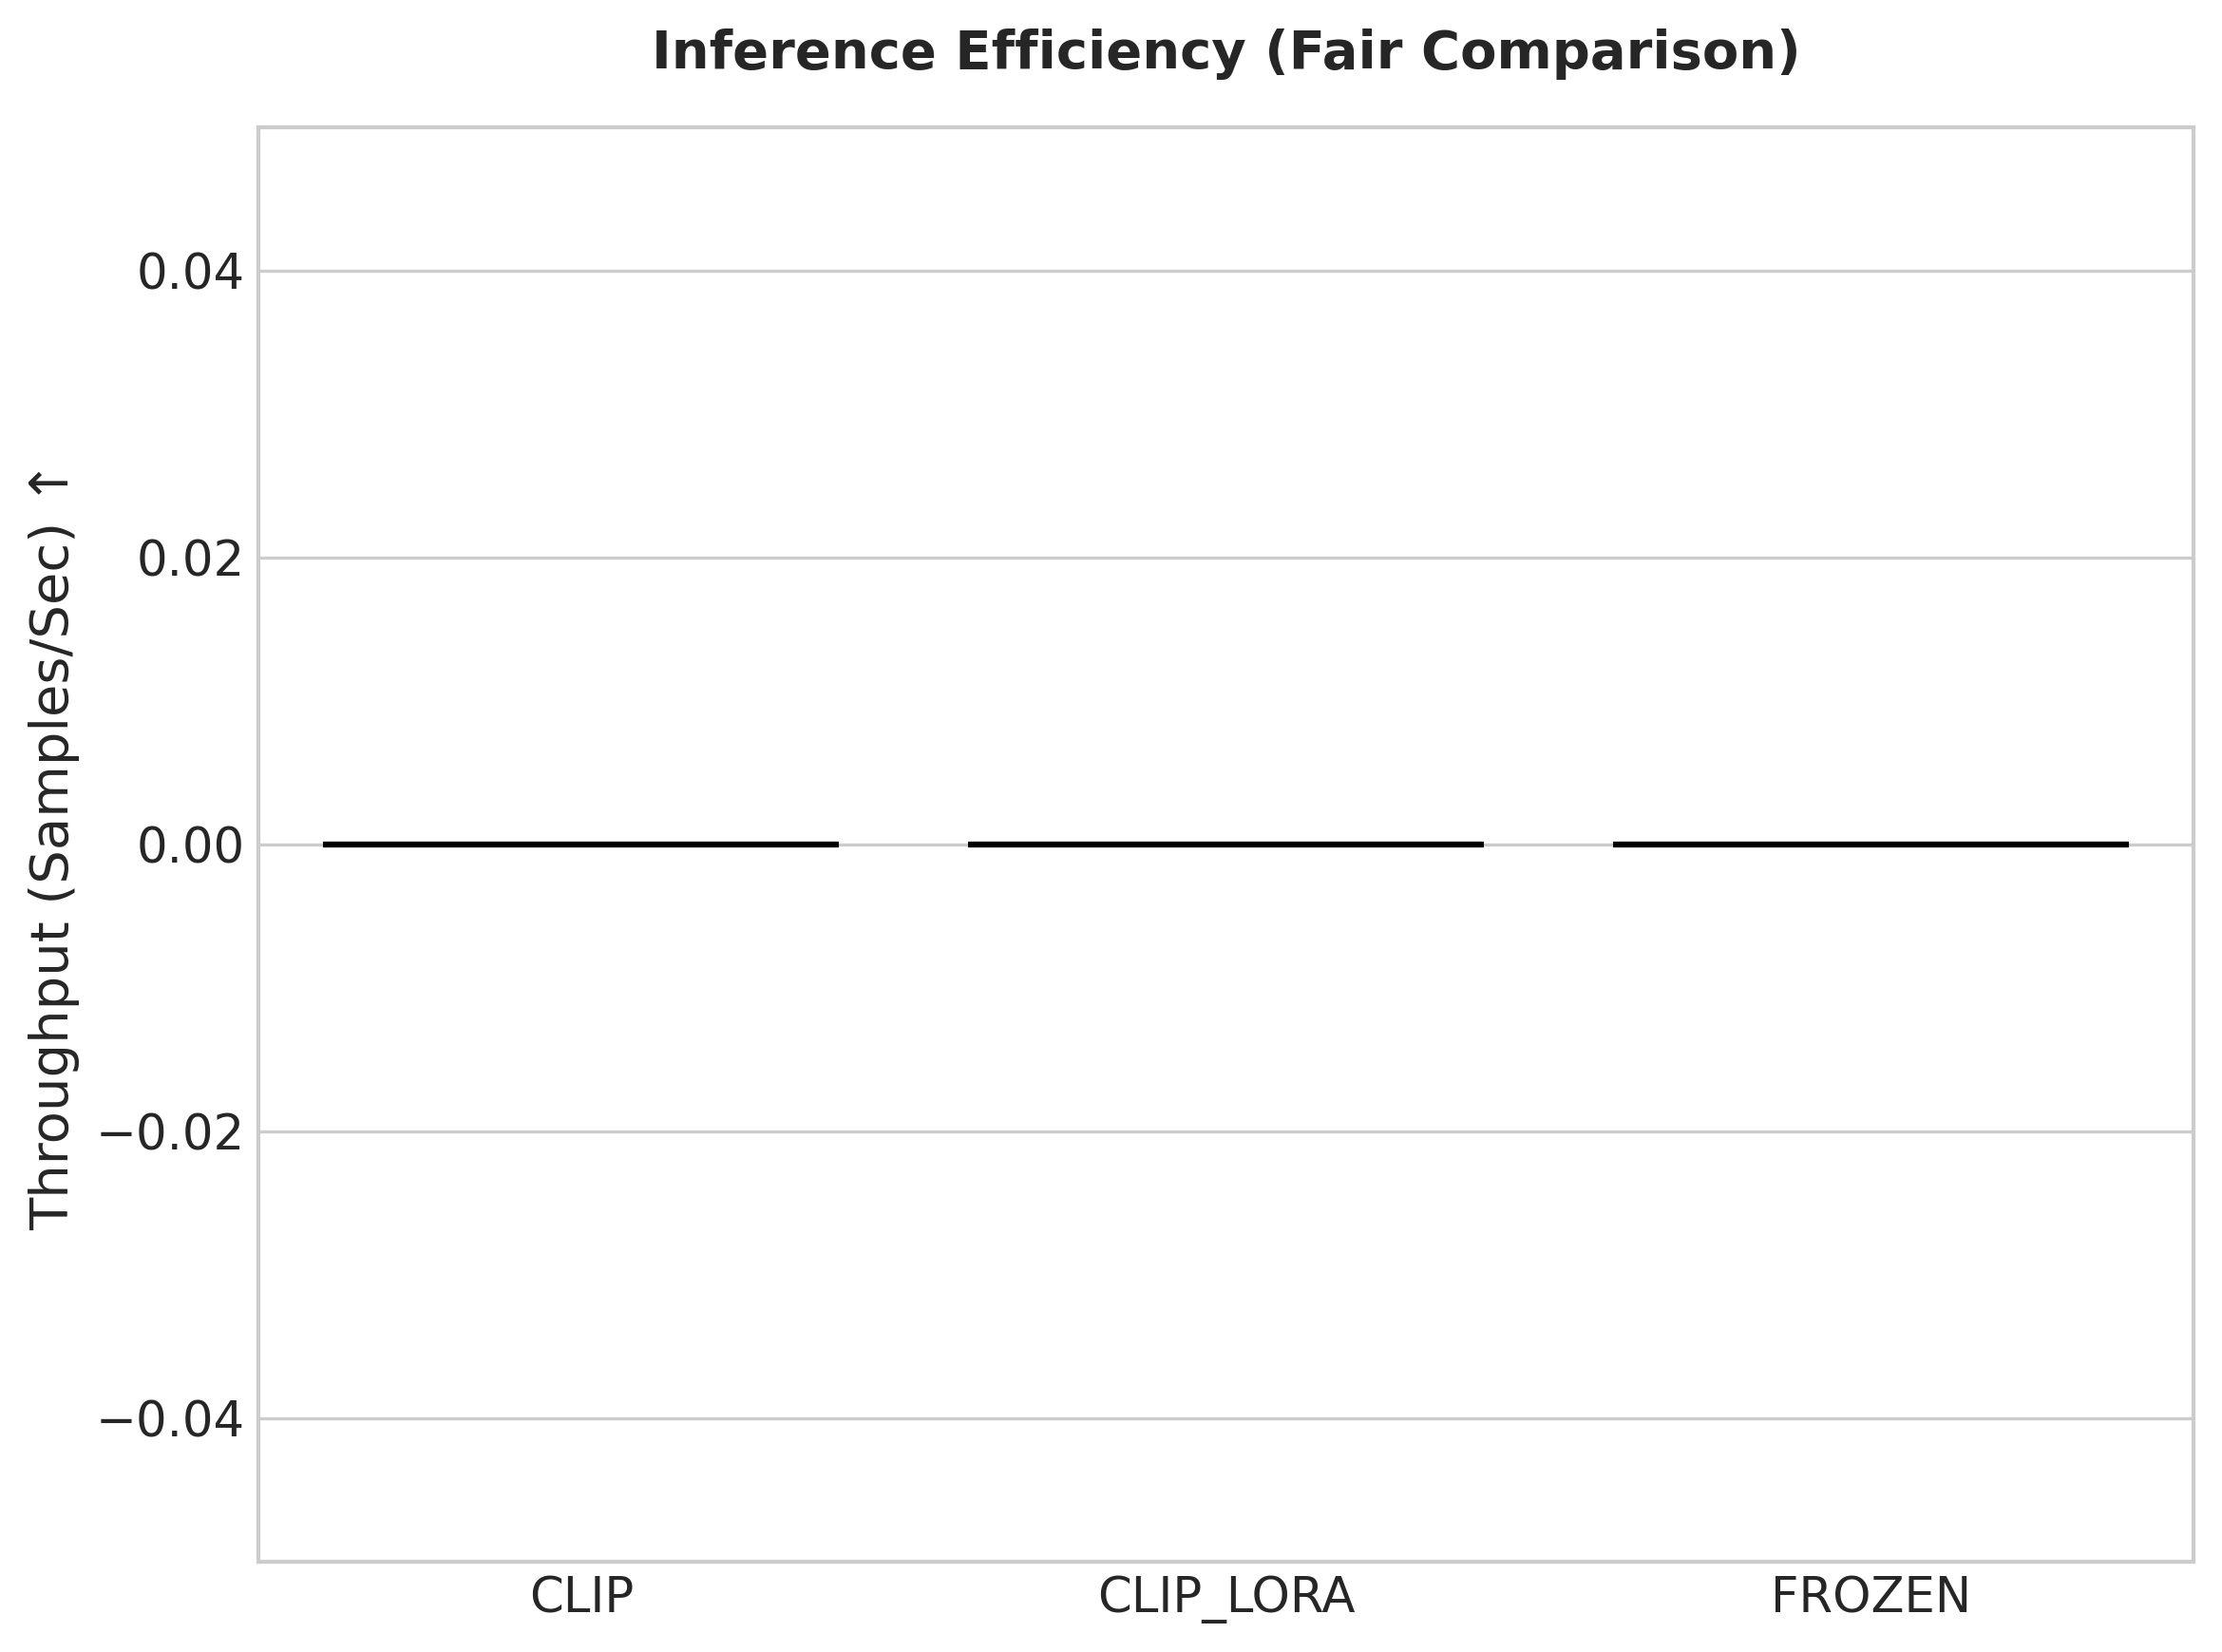

✓ Saved Fig1_Efficiency.png


/tmp/ipykernel_40862/434089929.py:82: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, data["Throughput"].max() * 1.25)


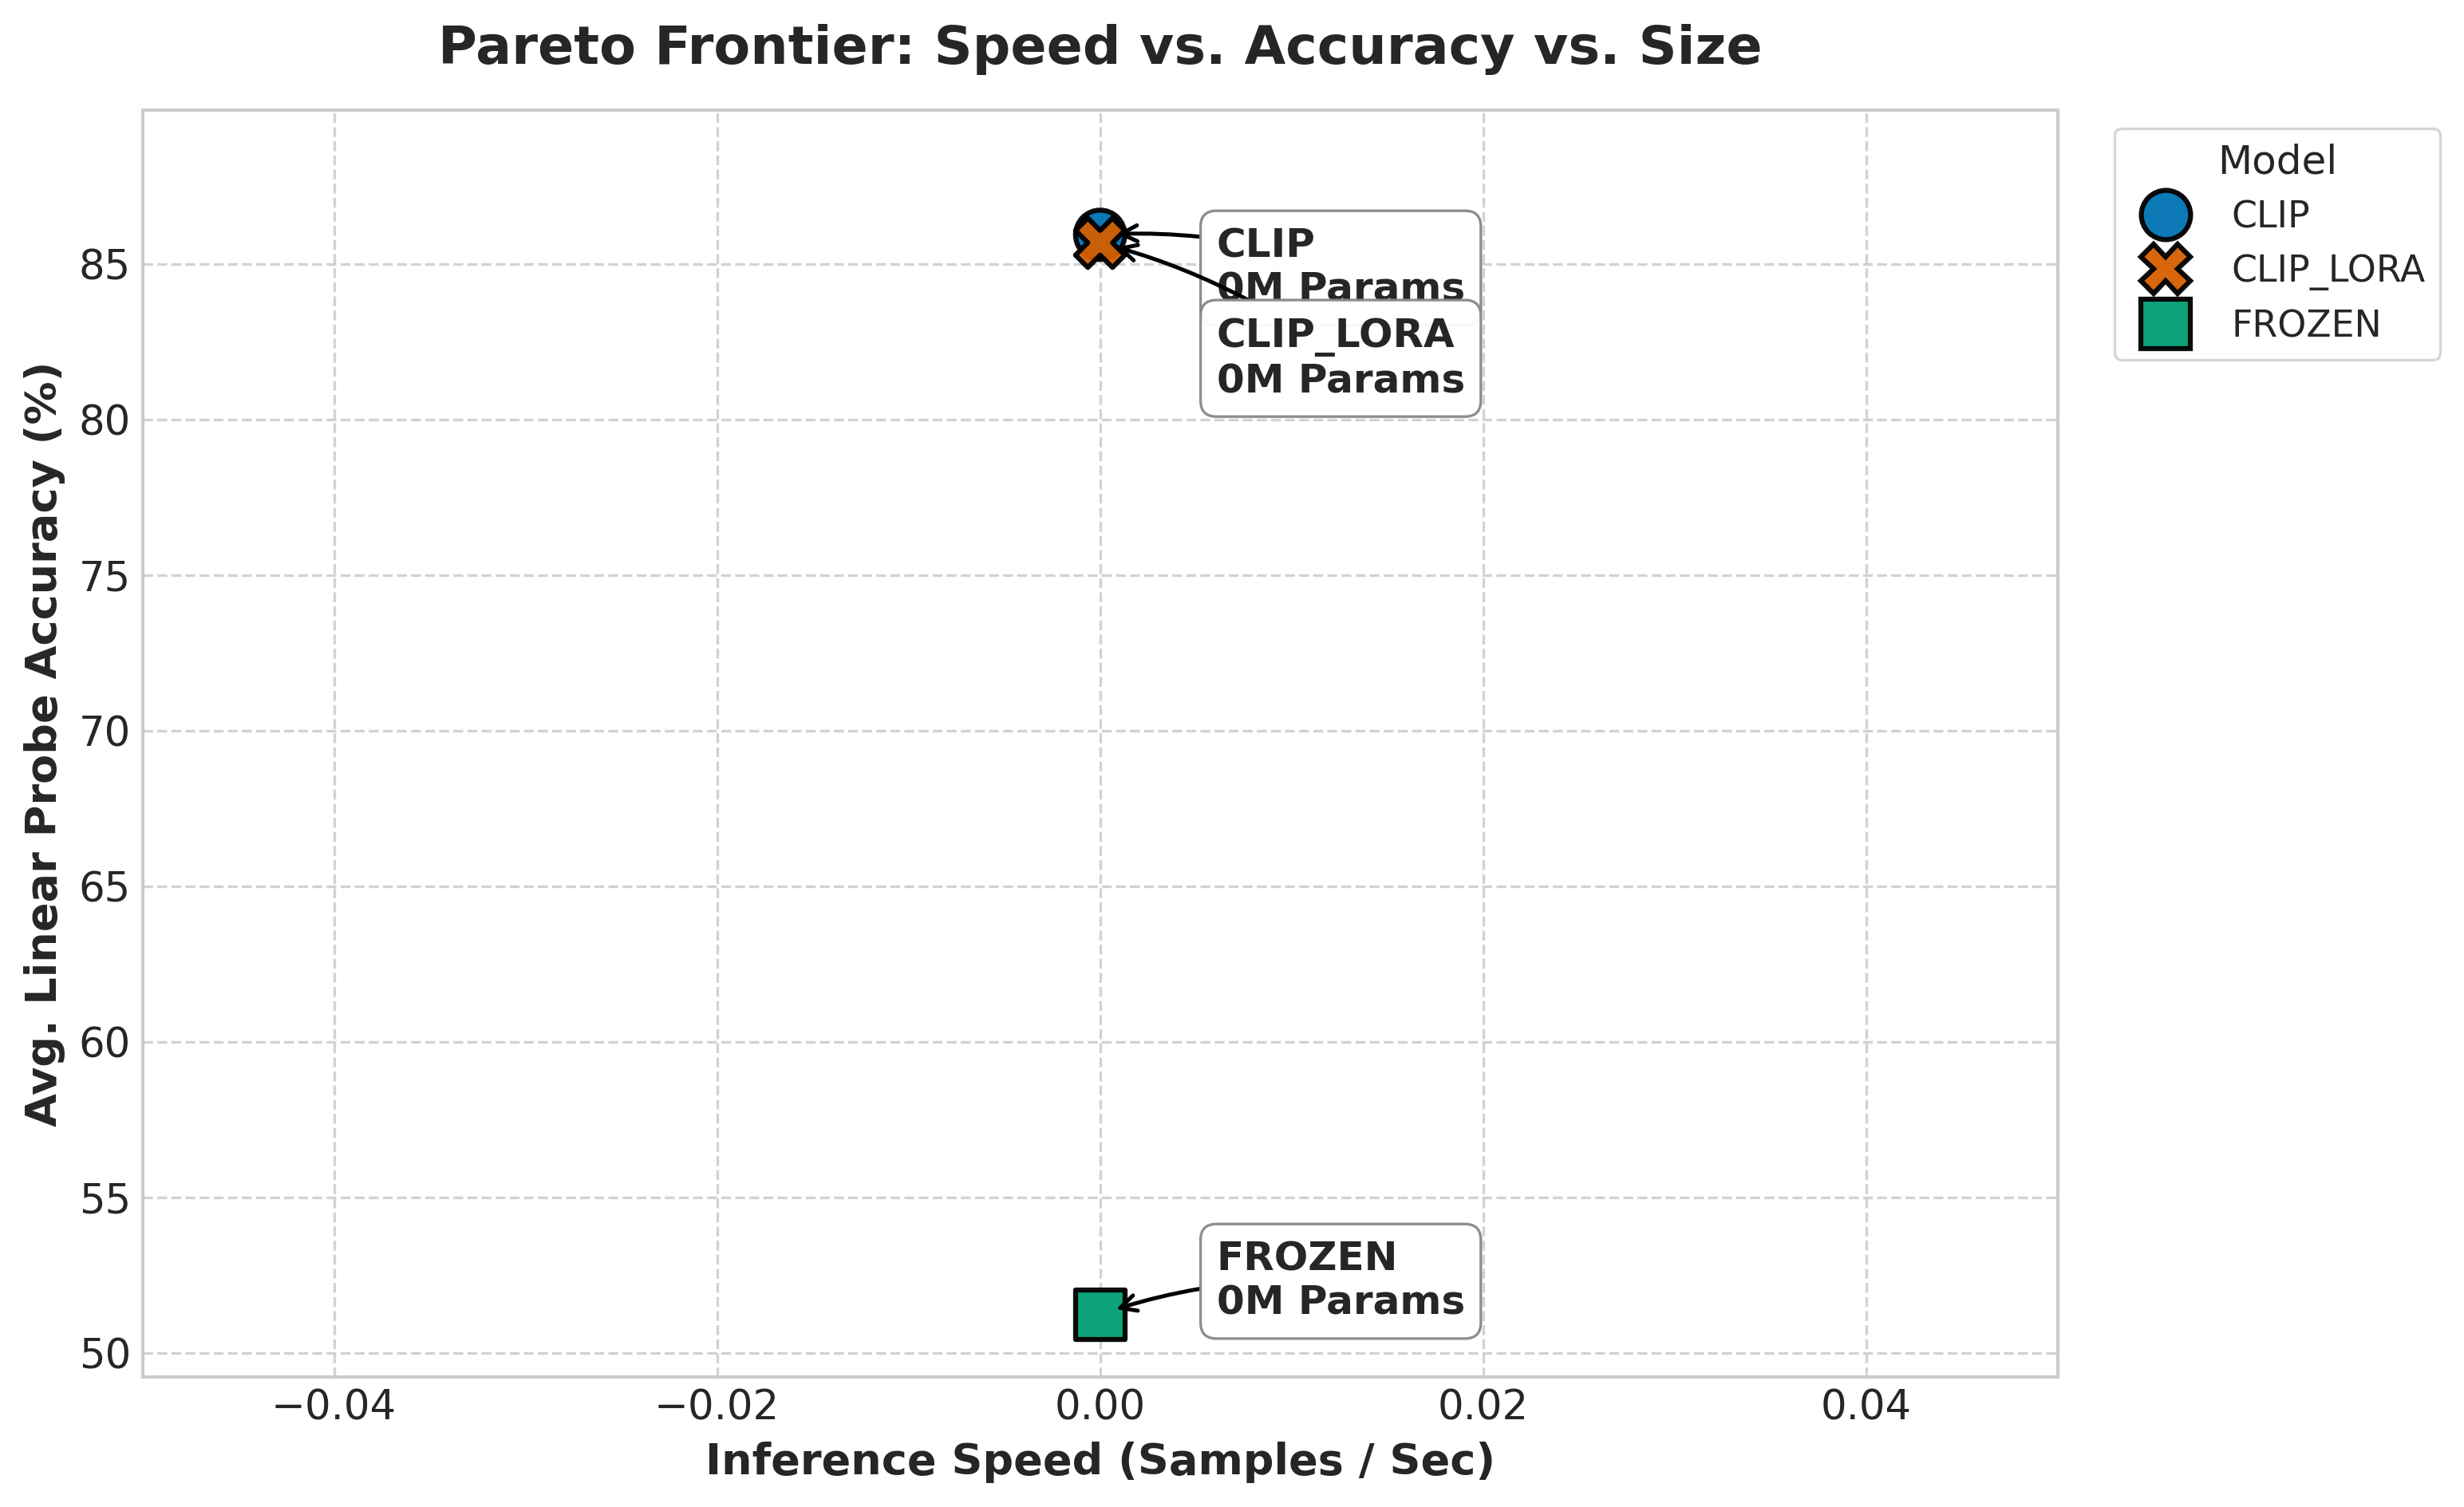

✓ Saved Fig2_Pareto_Frontier.png


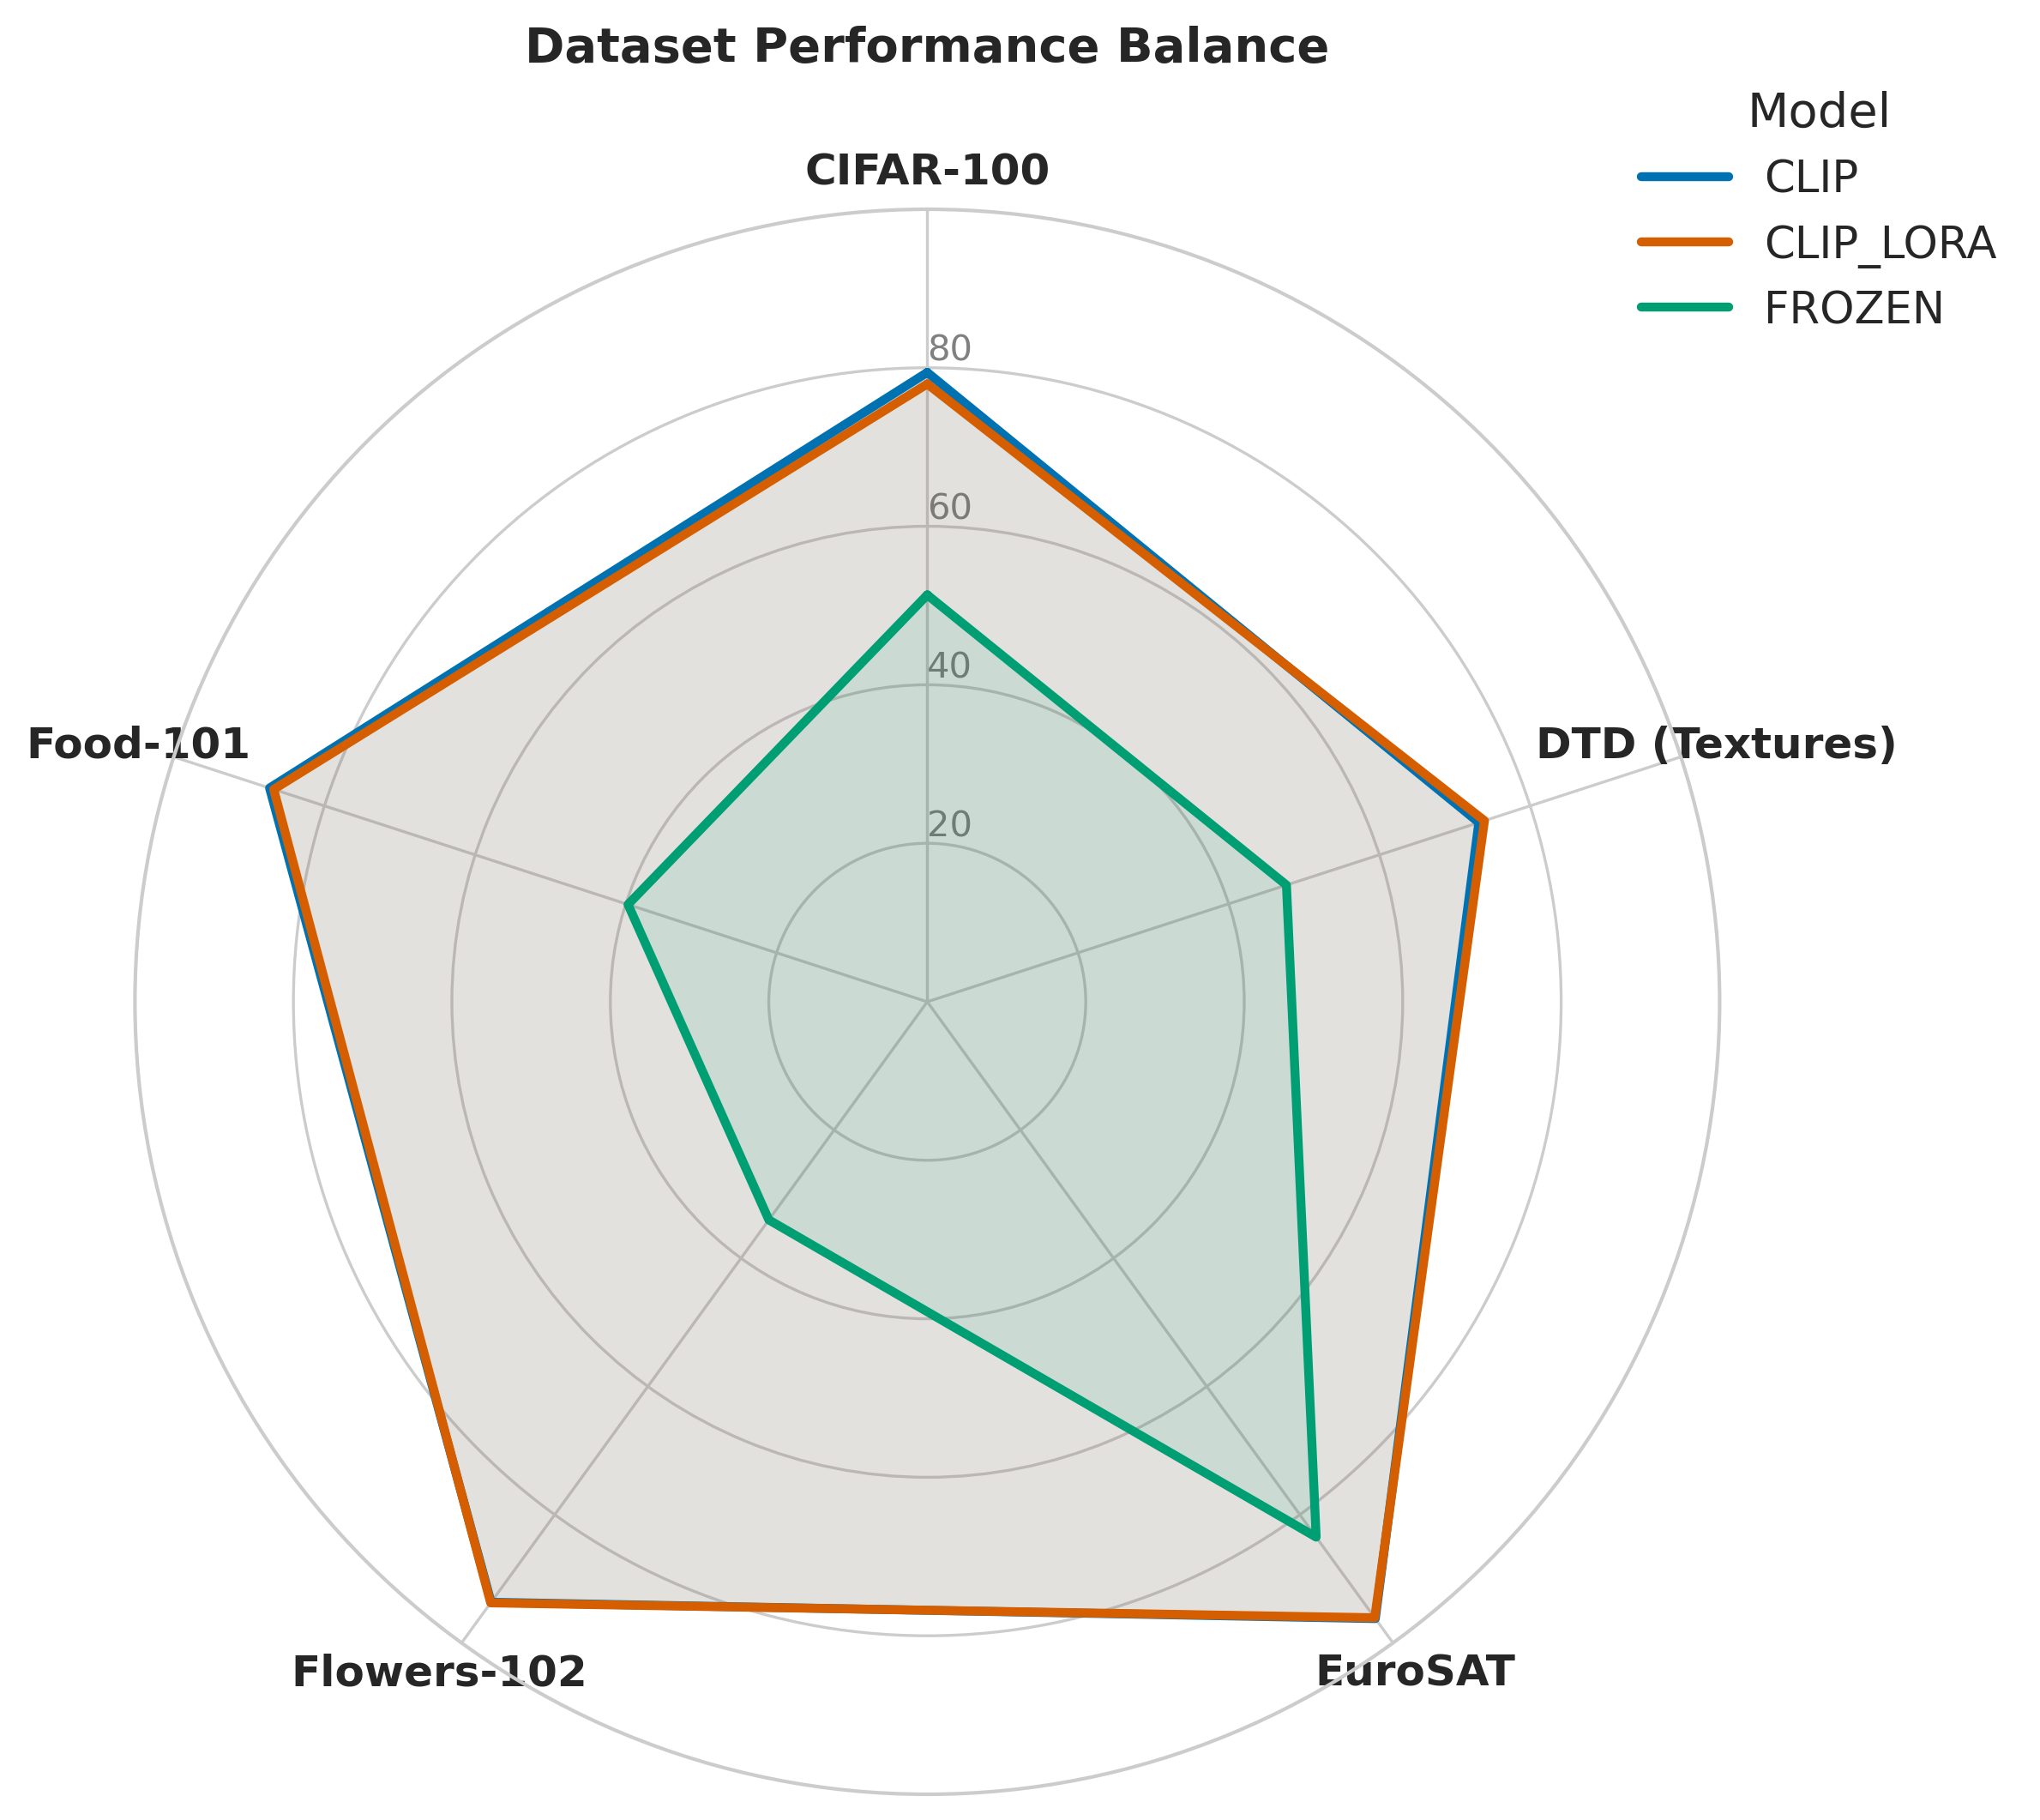

✓ Saved Fig3_Radar_Balance.png


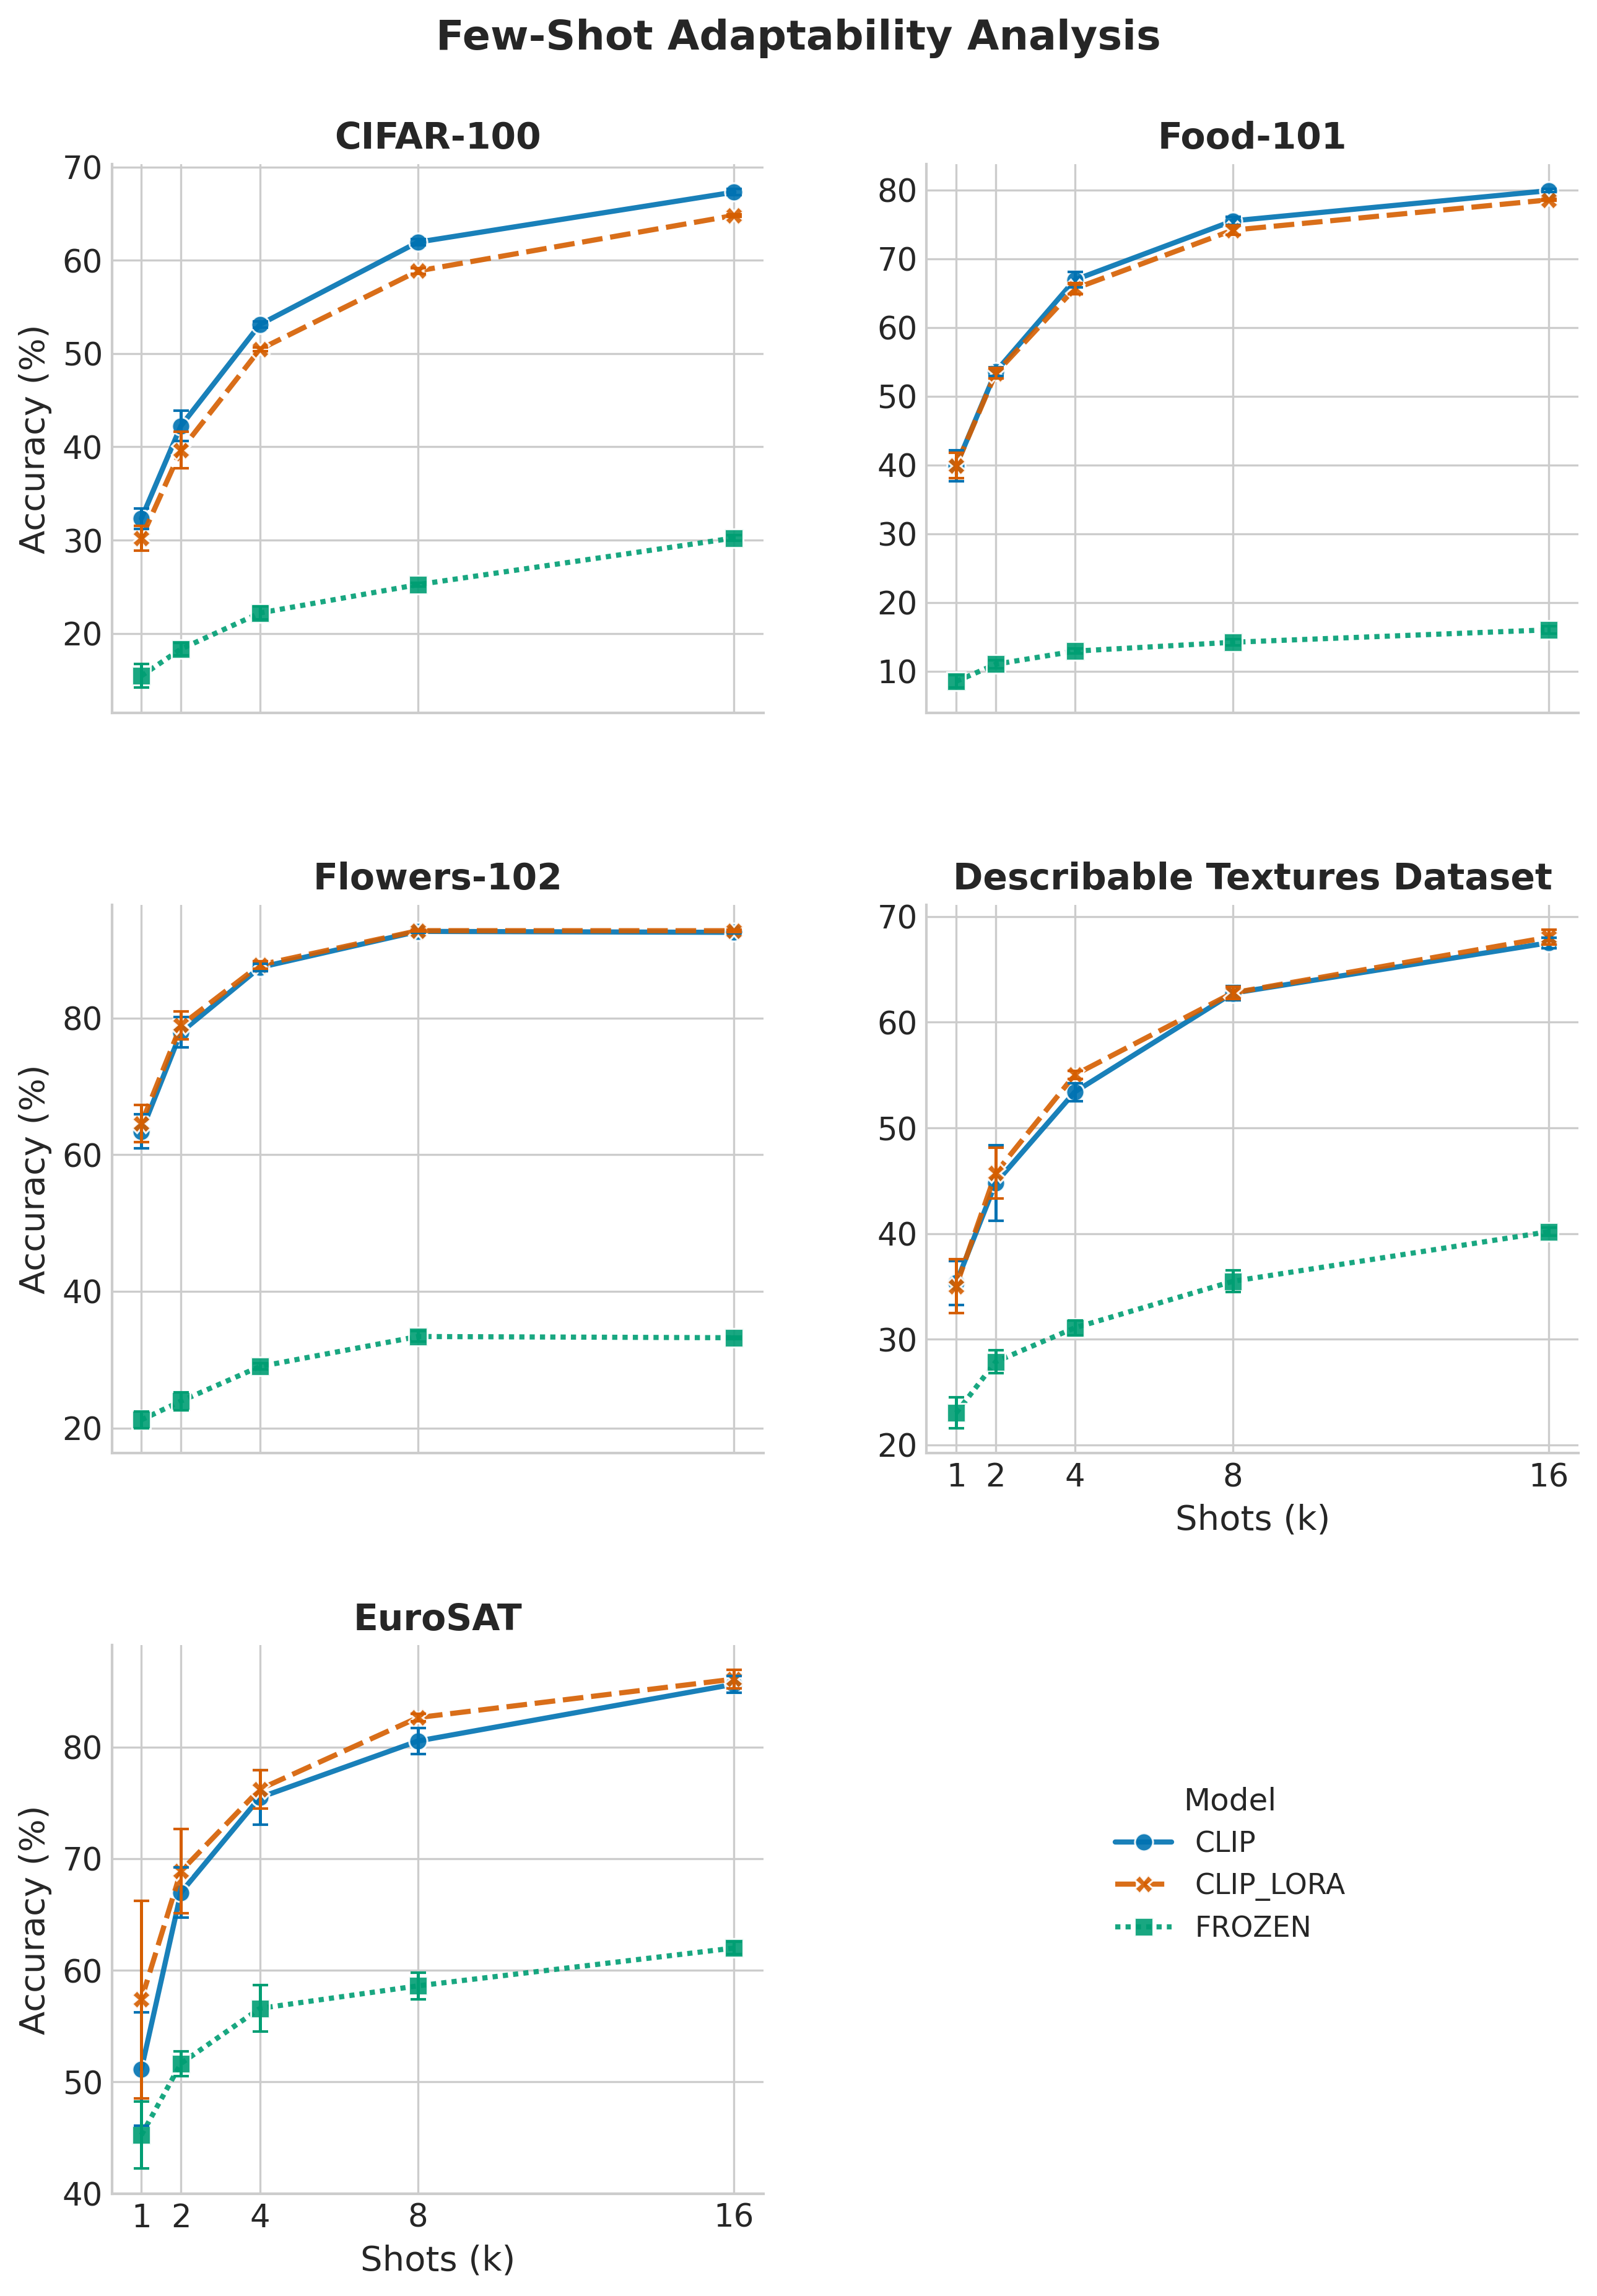

✓ Saved Fig4_FewShot_Curves.png

✓ Analysis Complete. Results saved to 'Results'


In [14]:
# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    print("Starting Analysis...")
    
    # 1. Load Data
    df, stats = load_all_data()
    
    if df.empty and not stats:
        print("\n❌ No data found! Check 'results_attained' folder structure.")
    else:
        print(f"✓ Loaded {len(df)} data points and {len(stats)} model stats.")
        
        # 2. Run Plots
        plot_efficiency(stats)
        plot_pareto_final(stats)
        plot_radar(df)
        plot_few_shot_curves(df)
        
        print(f"\n✓ Analysis Complete. Results saved to '{OUTPUT_DIR}'")

Saved figure as 'training_dynamics.png'


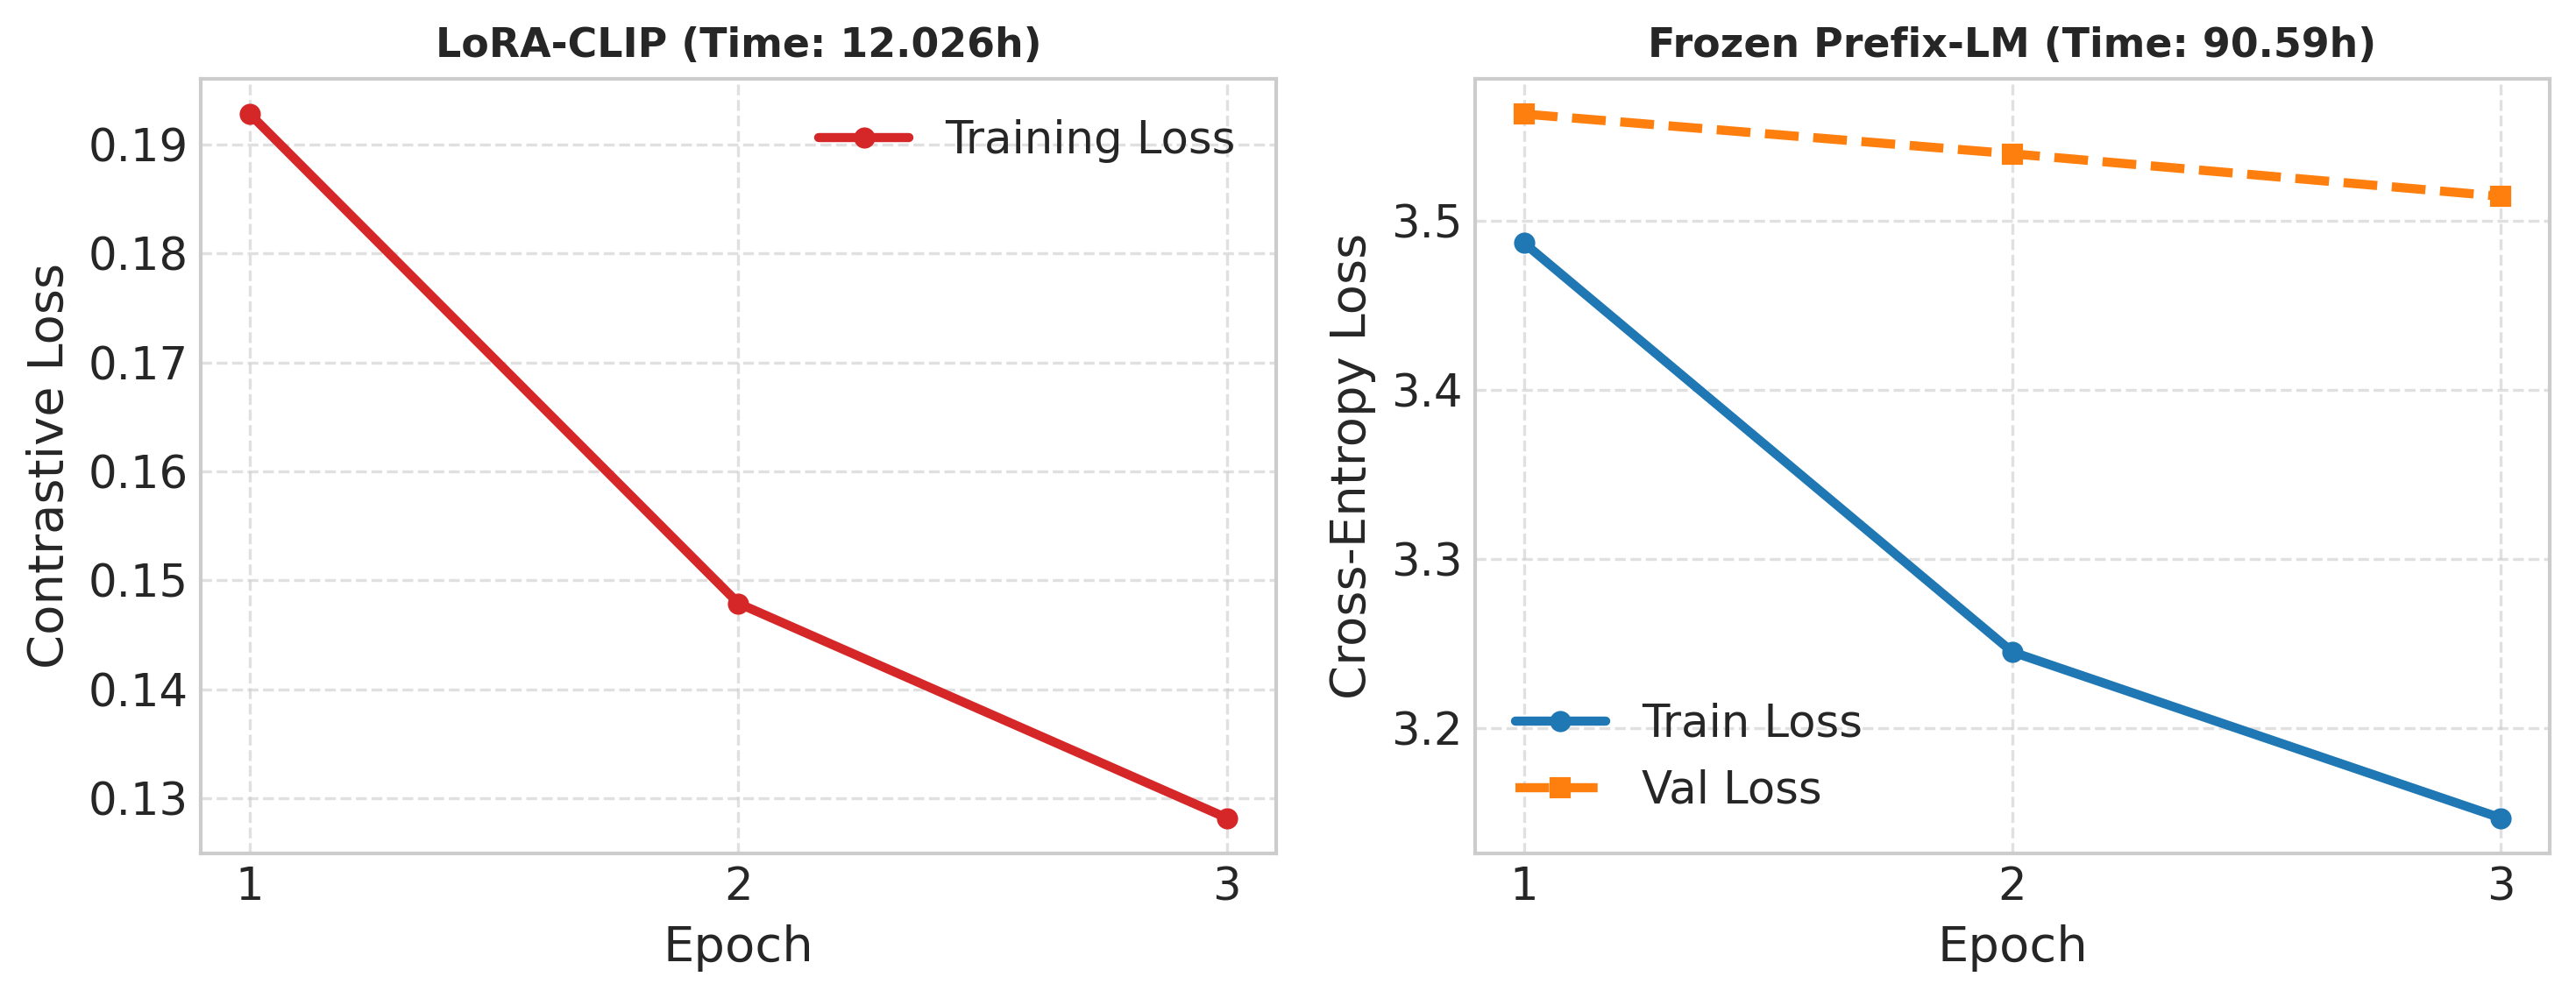

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA INPUT ---
epochs = [1, 2, 3]

# UPDATED LoRA Data (Corrected Metrics)
# Loss: [0.1927..., 0.1478..., 0.1282...]
lora_loss = [0.1928, 0.1479, 0.1282]
lora_time = 12.026  # Exact time from logs

# Frozen LM Data (Unchanged)
frozen_train = [3.4869, 3.2452, 3.1471]
frozen_val = [3.5630, 3.5395, 3.5144]
frozen_time = 90.59

# --- PLOTTING ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: LoRA-CLIP (Convergence)
ax1.plot(epochs, lora_loss, 'o-', color='#d62728', linewidth=2.5, label='Training Loss')
# Display time with 3 decimal places as requested
ax1.set_title(f'LoRA-CLIP (Time: {lora_time:.3f}h)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Contrastive Loss')
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2: Frozen Prefix-LM (Generalization)
ax2.plot(epochs, frozen_train, 'o-', color='#1f77b4', linewidth=2.5, label='Train Loss')
ax2.plot(epochs, frozen_val, 's--', color='#ff7f0e', linewidth=2.5, label='Val Loss')
ax2.set_title(f'Frozen Prefix-LM (Time: {frozen_time:.2f}h)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=300)
print("Saved figure as 'training_dynamics.png'")